Initial Shape: (1000, 19)
Full duplicates: 0
Key duplicates: 2
Shape after Task 1: (998, 19)

Missing Report (Task 2 initial):
            missing_count  missing_percent
alert                549        55.010020
location               6         0.601202
continent            714        71.543086
country              347        34.769539
Zeros in cdi: 395
Zeros in gap: 252
Zeros in nst: 519
Zeros in dmin: 586

Skewness of numeric columns:
magnitude    1.366560
cdi          0.151713
mmi         -0.266394
tsunami      0.754993
sig          3.458270
nst          0.802764
dmin         2.813414
gap          4.019792
depth        3.147067
latitude     0.231227
longitude   -0.694063
dtype: float64
['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude', 'longitude', 'location', 'continent', 'country']
                                      title  magnitude         date_time  cdi  \
0          M 6.5 - 42 km W of Sola

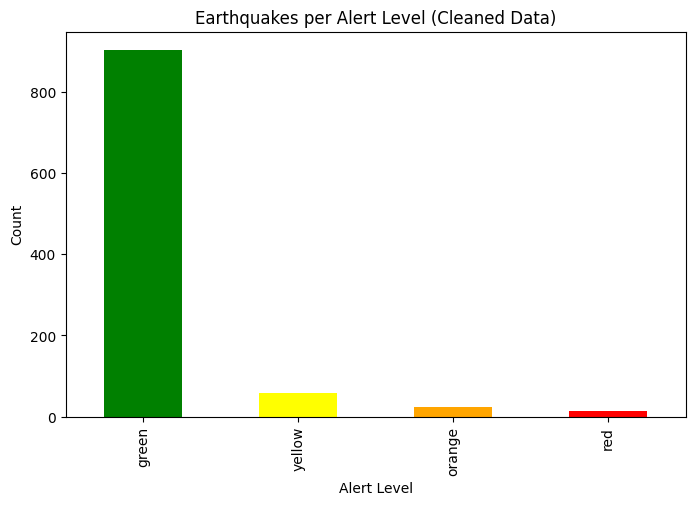

In [ ]:
import pandas as pd
import numpy as np
import os

file_path = "earthquake_1995-2023.csv"
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Initial Shape:", df.shape)

    # Task 1
    dup_full = df.duplicated().sum()
    dup_key = df.duplicated(subset=['title', 'date_time']).sum()
    print("Full duplicates:", dup_full)
    print("Key duplicates:", dup_key)

    df_clean1 = df.drop_duplicates()
    df_clean1 = df_clean1.drop_duplicates(subset=['title', 'date_time'])
    print("Shape after Task 1:", df_clean1.shape)

    # Task 2
    missing_report = pd.DataFrame({
        'missing_count': df_clean1.isnull().sum(),
        'missing_percent': (df_clean1.isnull().sum() / len(df_clean1)) * 100
    })
    print("\nMissing Report (Task 2 initial):\n", missing_report[missing_report['missing_count'] > 0])

    # Zeros
    cols_to_check = ['cdi', 'gap', 'nst', 'dmin']
    for col in cols_to_check:
        if col in df_clean1.columns:
            zeros = (df_clean1[col] == 0).sum()
            print(f"Zeros in {col}: {zeros}")

    print("\nSkewness of numeric columns:")
    print(df_clean1.select_dtypes(include=[np.number]).skew())

    print(df.columns.tolist())
    print(df.head(2))

    df_clean = df_clean1.copy()
    cols_to_replace = ['cdi', 'gap', 'nst', 'dmin']
    df_clean[cols_to_replace] = df_clean[cols_to_replace].replace(0, np.nan)
    print("Skewness after replacing 0s:")
    print(df_clean[['cdi', 'gap', 'nst', 'dmin']].skew())

    import matplotlib.pyplot as plt

    # Imputation
    df_clean['cdi'] = df_clean['cdi'].fillna(df_clean['cdi'].mean())
    df_clean['nst'] = df_clean['nst'].fillna(df_clean['nst'].mean())
    df_clean['gap'] = df_clean['gap'].fillna(df_clean['gap'].median())
    df_clean['dmin'] = df_clean['dmin'].fillna(df_clean['dmin'].median())

    # Categorical
    df_clean['alert'] = df_clean['alert'].fillna(df_clean['alert'].mode()[0])
    df_clean['location'] = df_clean['location'].fillna('Unknown')
    df_clean['continent'] = df_clean['continent'].fillna('Unknown')
    df_clean['country'] = df_clean['country'].fillna('Unknown')

    print("Remaining NaNs:")
    print(df_clean.isnull().sum().sum())

    # Plot
    plt.figure(figsize=(8,5))
    df_clean['alert'].value_counts().plot(kind='bar', color=['green', 'yellow', 'orange', 'red'])
    plt.title('Earthquakes per Alert Level (Cleaned Data)')
    plt.xlabel('Alert Level')
    plt.ylabel('Count')
    plt.savefig('chart.png')
    print("Chart saved")

else:
    print("File not found in the current directory.")

Dataset Shape: (1000, 19)

First 3 Records:
                                       title  magnitude         date_time  cdi  \
0          M 6.5 - 42 km W of Sola, Vanuatu        6.5  16/08/2023 12:47    7   
1  M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19/07/2023 00:22    8   
2  M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17/07/2023 03:05    7   

   mmi   alert  tsunami  sig net  nst   dmin   gap magType    depth  latitude  \
0    4   green        0  657  us  114  7.177  25.0     mww  192.955  -13.8814   
1    6  yellow        0  775  us   92  0.679  40.0     mww   69.727   12.8140   
2    5   green        0  899  us   70  1.634  28.0     mww  171.371  -38.1911   

   longitude               location      continent    country  
0   167.1580          Sola, Vanuatu            NaN    Vanuatu  
1   -88.1265  Intipucá, El Salvador            NaN        NaN  
2   -70.3731    Loncopué, Argentina  South America  Argentina  

Dataset Info:
<class 'pandas.core.frame.DataFram

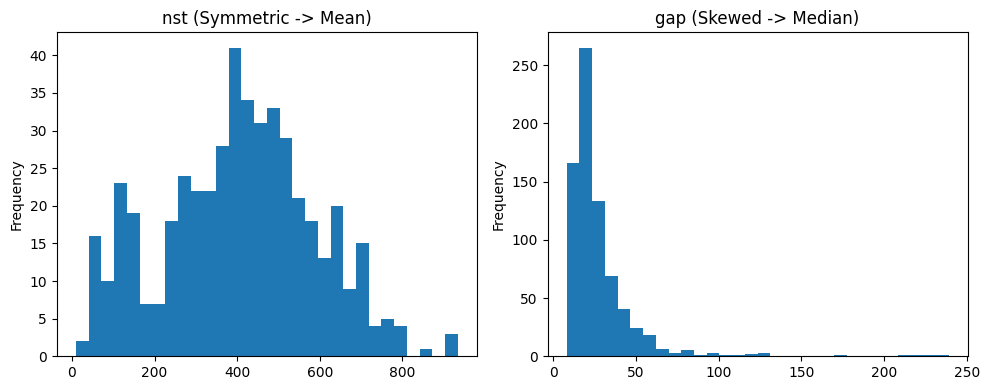


Remaining Missing Values in Dataset: 0


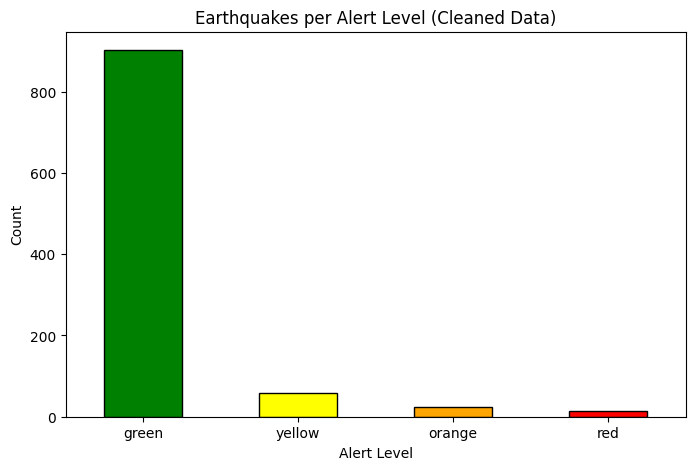

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('earthquake_1995-2023.csv')

# 1. Structural Profile
print("Dataset Shape:", df.shape)
print("\nFirst 3 Records:\n", df.head(3))
print("\nDataset Info:")
df.info()

# 2. Duplicate Detection
# (a) Fully identical rows
full_dupes = df.duplicated().sum()
print(f"\nFully identical duplicate rows: {full_dupes}")

# (b) Meaningful key repeats (title and date_time)
key_dupes = df.duplicated(subset=['title', 'date_time']).sum()
print(f"Duplicates based on 'title' and 'date_time': {key_dupes}")

# Remove duplicates
print(f"\nRow count before removal: {len(df)}")
df_clean = df.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset=['title', 'date_time'])
print(f"Row count after removal: {len(df_clean)}")

# Missing-Value Report
missing_report = pd.DataFrame({
    'Missing Count': df_clean.isnull().sum(),
    'Missing %': (df_clean.isnull().sum() / len(df_clean)) * 100
})
print("Initial Missing Values:\n", missing_report[missing_report['Missing Count'] > 0])

# Investigate and replace placeholder zeros
cols_to_check = ['cdi', 'gap', 'nst', 'dmin']
for col in cols_to_check:
    zero_count = (df_clean[col] == 0).sum()
    print(f"Zeros in {col}: {zero_count}")

df_clean[cols_to_check] = df_clean[cols_to_check].replace(0, np.nan)

# Verify skewness for imputation justification
print("\nSkewness after replacing 0s:")
print(df_clean[cols_to_check].skew())

# Distribution Visualization (To justify Mean vs Median visually)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_clean['nst'].plot(kind='hist', bins=30, ax=axes[0], title='nst (Symmetric -> Mean)')
df_clean['gap'].plot(kind='hist', bins=30, ax=axes[1], title='gap (Skewed -> Median)')
plt.tight_layout()
plt.show()

# Imputation Implementation
df_clean['cdi'] = df_clean['cdi'].fillna(df_clean['cdi'].mean())
df_clean['nst'] = df_clean['nst'].fillna(df_clean['nst'].mean())
df_clean['gap'] = df_clean['gap'].fillna(df_clean['gap'].median())
df_clean['dmin'] = df_clean['dmin'].fillna(df_clean['dmin'].median())

# Categorical Fill
df_clean['alert'] = df_clean['alert'].fillna(df_clean['alert'].mode()[0])
df_clean['location'] = df_clean['location'].fillna('Unknown')
df_clean['continent'] = df_clean['continent'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')

# Verification
print("\nRemaining Missing Values in Dataset:", df_clean.isnull().sum().sum())

# Cleaned Data Visualization
plt.figure(figsize=(8, 5))
alert_counts = df_clean['alert'].value_counts()
alert_colors = ['green', 'yellow', 'orange', 'red'][:len(alert_counts)]
alert_counts.plot(kind='bar', color=alert_colors, edgecolor='black')
plt.title('Earthquakes per Alert Level (Cleaned Data)')
plt.xlabel('Alert Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()